# NAMA      : SRI ZUL'AINI ULYA
# NIM       : F1D02410096
# KELOMPOK  : 10

In [72]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt

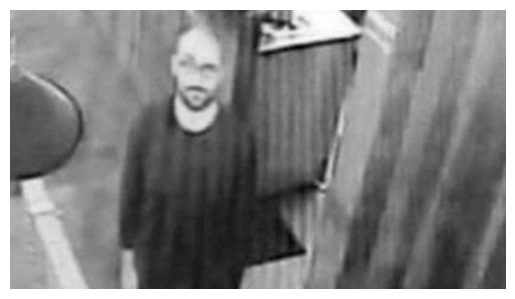

In [73]:
def show(img, title=""):
    plt.imshow(img, cmap='gray')
    plt.title(title)  
    plt.axis('off')

cctv = plt.imread("backup.jpg")
img_gray = cv.cvtColor(cctv, cv.COLOR_RGB2GRAY)
if img_gray.dtype != np.uint8:
    img_gray = (img_gray * 255).astype(np.uint8)

show(img_gray)

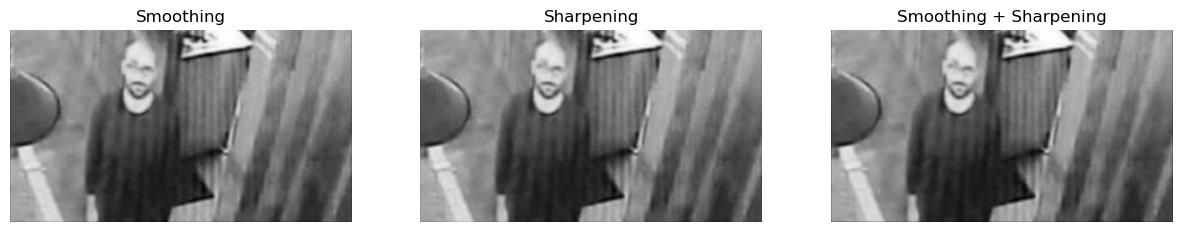

In [74]:
def convolution(img, kernel):
    size = kernel.shape[0]
    pad_size = size // 2
    padded = np.pad(img, pad_size, mode='constant')
    canvas = np.zeros_like(img).astype(np.float32)
    height, width = img.shape
    
    for i in range(height):
        for j in range(width):
            region = padded[i:i+size, j:j+size]
            canvas[i, j] = np.sum(region * kernel)
            
    return canvas

kernelSmoothing = np.array([
    [1/10, 1/10, 1/10],
    [1/10, 1/5, 1/10],
    [1/10, 1/10, 1/10]
])

kernelSharpening = np.array([
    [1/9, 1/9, 1/9],
    [1/9, 8/9, 1/9],
    [1/9, 1/9, 1/9]
])

img_smoothed = convolution(img_gray, kernelSmoothing)
img_sharpened = convolution(img_gray, kernelSharpening)
img_smootpened = convolution(img_smoothed, kernelSharpening)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
show(img_smoothed, 'Smoothing')

plt.subplot(1, 3, 2)
show(img_sharpened, 'Sharpening')

plt.subplot(1, 3, 3)
show(img_smootpened, 'Smoothing + Sharpening')

# Perbedaan Metode Smoothing, Sharpening, dan Kombinasi

Ketiga metode ini menggunakan teknik konvolusi namun dengan matriks *kernel* yang berbeda, sehingga menghasilkan efek visual yang berbeda pada citra:

* **Smoothing (Penghalusan)**
  * **Kegunaan:** Mengurangi *noise* (bintik/gangguan) dan menyamarkan tekstur kasar pada gambar.
  * **Perbedaan/Efek:** Matriks kernel membagi bobot secara merata ke piksel sekitarnya (rata-rata). Hasilnya, gambar akan terlihat lebih *blur* (kabur), transisi warna menjadi lebih lembut, namun detail tepi (*edge*) objek akan ikut memudar.

* **Sharpening (Penajaman)**
  * **Kegunaan:** Mempertegas batas tepi (*edge*) dan detail objek pada citra agar terlihat lebih fokus.
  * **Perbedaan/Efek:** Matriks kernel memberikan bobot yang sangat besar pada piksel tengah. Hasilnya, kontras antara piksel yang berdekatan akan meningkat secara drastis. Kelemahannya, jika gambar asli memiliki *noise*, *noise* tersebut akan ikut menajam dan membuat gambar terlihat "kotor".

* **Kombinasi (Smoothing + Sharpening)**
  * **Kegunaan:** Memperjelas detail objek sekaligus meminimalisir *noise* pada citra.
  * **Perbedaan/Efek:** Ini adalah pendekatan hibrida. Gambar dihaluskan terlebih dahulu (Smoothing) untuk menyapu bintik *noise*, kemudian gambar yang sudah bersih tersebut dipertajam (Sharpening). Hasil akhirnya adalah citra dengan batas objek yang tegas, namun terbebas dari bintik-bintik *noise* yang mengganggu.

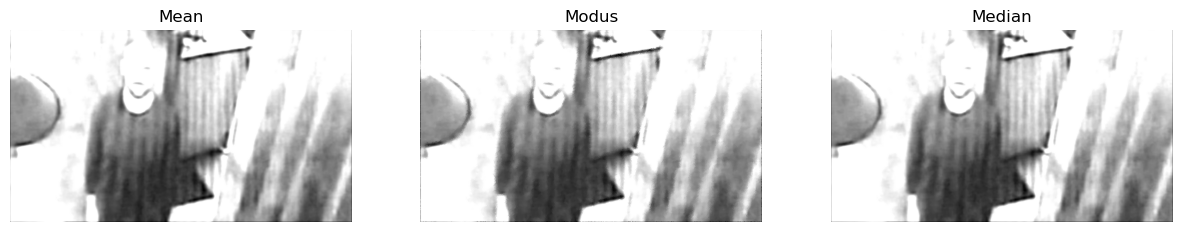

In [75]:
def filter(img, size, mode):
    height, width = img.shape
    pad_size = size // 2
    
    padded = np.pad(img, pad_size, mode='edge')
    canvas = np.zeros((height, width), dtype=np.uint8)

    match mode:
        case 'mean':
            for i in range(height):
                for j in range(width):
                    region = padded[i:i+size, j:j+size]
                    value = int(np.mean(region))
                    canvas[i, j] = np.clip(value, 0, 255)

        case 'median':
            for i in range(height):
                for j in range(width):
                    region = padded[i:i+size, j:j+size]
                    value = int(np.median(region))
                    canvas[i, j] = np.clip(value, 0, 255)

        case 'modus':
            for i in range(height):
                for j in range(width):
                    region = padded[i:i+size, j:j+size]
                    values = region.ravel()

                    count = {}

                    for val in values:
                        val = int(val)

                        if val in count:
                            count[val] += 1
                        else:
                            count[val] = 1

                    max_count = 0
                    mode_val = 0

                    for val, freq in count.items():
                        if freq > max_count:
                            max_count = freq
                            mode_val = val

                    canvas[i, j] = np.clip(mode_val, 0, 255)

    return canvas


img_mean = filter(img_smootpened, 3, 'mean')
img_modus = filter(img_smootpened, 3, 'modus')
img_median = filter(img_smootpened, 3, 'median')

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
show(img_mean, 'Mean')

plt.subplot(1, 3, 2)
show(img_modus, 'Modus')

plt.subplot(1, 3, 3)
show(img_median, 'Median')

plt.show()

# Perbedaan Hasil Filter Mean, Median, dan Modus

Ketiga filter ini memanipulasi nilai piksel menggunakan pendekatan statistik (bukan sekadar perkalian matriks linear), dan masing-masing memberikan efek yang sangat khas:

* **Mean (Rata-rata)**
  * **Cara kerja:** Menjumlahkan seluruh nilai piksel di dalam *window* (area kernel) lalu membaginya rata.
  * **Hasil visual:** Menghasilkan efek *blur* yang merata ke seluruh bagian gambar. Filter ini kurang ideal jika kamu ingin mempertahankan detail, karena garis batas objek akan langsung ikut kabur.

* **Median (Nilai Tengah)**
  * **Cara kerja:** Mengurutkan seluruh nilai piksel dari yang terkecil hingga terbesar, lalu mengambil nilai tepat di tengah.
  * **Hasil visual:** Sangat ampuh untuk menghilangkan *salt-and-pepper noise* (bintik hitam/putih yang ekstrem). Keunggulan utamanya adalah **mampu menjaga ketajaman garis tepi objek** (*edge-preserving*), sehingga gambar bersih tanpa menjadi kabur.

* **Modus (Nilai Terbanyak)**
  * **Cara kerja:** Mencari intensitas warna piksel yang paling sering muncul di dalam area *window*.
  * **Hasil visual:** Cenderung menyeragamkan area dengan warna yang mirip menjadi satu warna solid. Hasil akhirnya membuat gambar kehilangan tekstur halus dan gradasi aslinya, sehingga tampak terblok-blok menyerupai efek poster atau kartun.

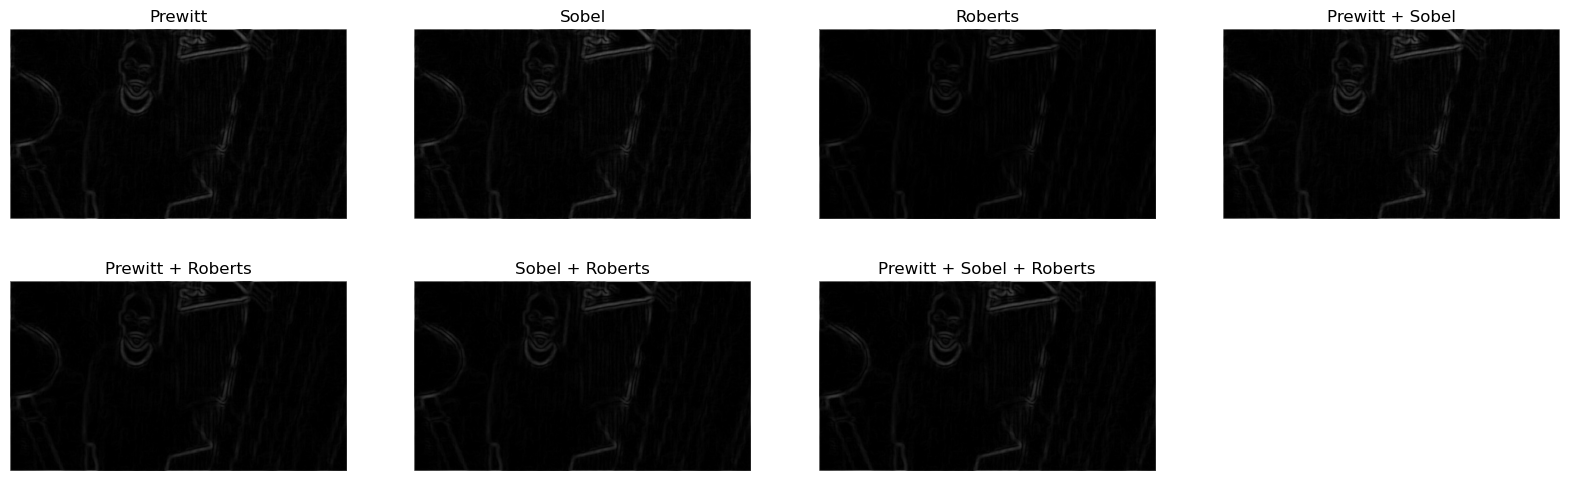

In [76]:
prewittx = np.array([
    [-1, 0, 1],
    [-1, 0, 1],
    [-1, 0, 1]
], dtype=np.float32)

prewitty = np.array([
    [1, 1, 1],
    [0, 0, 0],
    [-1, -1, -1]
], dtype=np.float32)

sobelx = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
], dtype=np.float32)

sobely = np.array([
    [1, 2, 1],
    [0, 0, 0],
    [-1, -2, -1]
], dtype=np.float32)

robertsx = np.array([
    [1, 0],
    [0, -1]
], dtype=np.float32)

robertsy = np.array([
    [0, 1],
    [-1, 0]
], dtype=np.float32)

def edge(img, kernelx, kernely):
    gx = convolution(img, kernelx)
    gy = convolution(img, kernely)
    
    canvas = np.zeros_like(img, dtype=np.float32)
    canvas = np.abs(gx) + np.abs(gy)
    canvas = canvas * 255.0 / np.max(canvas)
    
    return np.clip(canvas, 0, 255).astype(np.uint8)

img_prewitt = edge(img_smootpened, prewittx, prewitty)
img_sobel = edge(img_smootpened, sobelx, sobely)
img_roberts = edge(img_smootpened, robertsx, robertsy)

def combine_and_normalize(*images):
    combined = np.zeros_like(images[0], dtype=np.float32)
    for img in images:
        combined += img.astype(np.float32)
    combined = combined * 255.0 / np.max(combined)
    return np.clip(combined, 0, 255).astype(np.uint8)

prebel = combine_and_normalize(img_prewitt, img_sobel)
prerob = combine_and_normalize(img_prewitt, img_roberts)
belrob = combine_and_normalize(img_sobel, img_roberts)
prebelrob = combine_and_normalize(img_prewitt, img_sobel, img_roberts)


plt.figure(figsize=(20, 6))

plt.subplot(2, 4, 1)
show(img_prewitt, 'Prewitt')

plt.subplot(2, 4, 2)
show(img_sobel, 'Sobel')

plt.subplot(2, 4, 3)
show(img_roberts, 'Roberts')

plt.subplot(2, 4, 4)
show(prebel, 'Prewitt + Sobel')

plt.subplot(2, 4, 5)
show(prerob, 'Prewitt + Roberts')

plt.subplot(2, 4, 6)
show(belrob, 'Sobel + Roberts')

plt.subplot(2, 4, 7)
show(prebelrob, 'Prewitt + Sobel + Roberts')

**1. Kegunaan Masing-Masing Operator**
* **Operator Sobel:** Digunakan untuk mendeteksi tepi vertikal dan horizontal. Memiliki bobot lebih tinggi di titik tengah (bernilai 2), sehingga memberikan sedikit efek *smoothing* (penghalusan) bawaan. Hal ini membuat Sobel menghasilkan garis kontur yang lebih tebal, tegas, dan tangguh terhadap gangguan *noise*.
* **Operator Prewitt:** Bekerja mirip dengan Sobel untuk mendeteksi arah vertikal dan horizontal, namun tidak memiliki pembobotan lebih di titik tengah (nilainya rata 1). Hasilnya, Prewitt bisa sedikit lebih sensitif dalam merespons perubahan intensitas, namun perlindungannya terhadap bintik *noise* tidak sebaik Sobel.
* **Operator Roberts:** Menggunakan matriks silang berukuran kecil (2x2) yang secara spesifik menyoroti perubahan kontras diagonal. Operator ini sangat handal untuk mendeteksi tepi yang sangat tipis dan halus, tetapi kelemahan terbesarnya adalah sangat rentan menangkap *noise* kecil sebagai garis tepi.

**2. Kegunaan Melakukan Kombinasi Operator**
* **Saling Melengkapi Detail:** Tidak ada satu pun filter deteksi tepi yang sempurna untuk segala kondisi. Dengan menggabungkan operator, kita dapat menutupi kelemahan satu sama lain. Contohnya, menggabungkan **Sobel/Prewitt dengan Roberts** berarti kita mengambil kekuatan penangkapan "garis lurus" dari Sobel/Prewitt, dan melengkapinya dengan sensitivitas "garis diagonal halus" milik Roberts.
* **Membentuk Kontur yang Solid:** Menjumlahkan hasil respons berbagai arah dari beberapa matriks akan menciptakan peta tepi yang jauh lebih padat, komprehensif, dan utuh dibandingkan jika hanya menggunakan satu matriks.
* **Fungsi Normalisasi:** Kombinasi dilakukan dengan cara menjumlahkan matriks. Normalisasi di tahap akhir wajib dilakukan agar total nilai gabungan tersebut dikonversi kembali secara proporsional ke rentang piksel standar (0-255), mencegah kerusakan gambar akibat nilai yang terlalu terang (*overflow*).

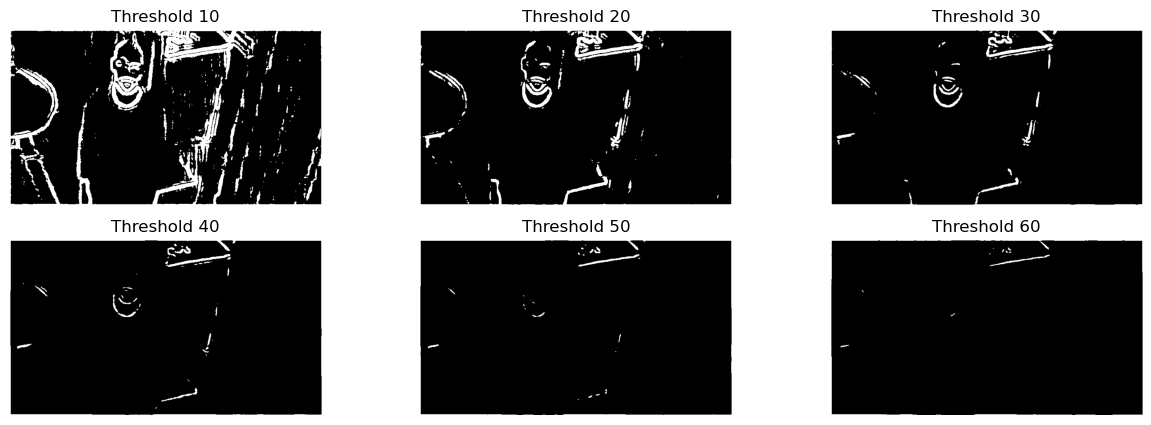

In [77]:
img_edge_final = img_sobel

img_thresh_10 = np.where(img_edge_final > 10, 255, 0).astype(np.uint8)
img_thresh_20 = np.where(img_edge_final > 20, 255, 0).astype(np.uint8)
img_thresh_30 = np.where(img_edge_final > 30, 255, 0).astype(np.uint8)
img_thresh_40 = np.where(img_edge_final > 40, 255, 0).astype(np.uint8)
img_thresh_50 = np.where(img_edge_final > 50, 255, 0).astype(np.uint8)
img_thresh_60 = np.where(img_edge_final > 60, 255, 0).astype(np.uint8)

plt.figure(figsize=(15, 5))

plt.subplot(2, 3, 1)
show(img_thresh_10, 'Threshold 10')

plt.subplot(2, 3, 2)
show(img_thresh_20, 'Threshold 20')

plt.subplot(2, 3, 3)
show(img_thresh_30, 'Threshold 30')

plt.subplot(2, 3, 4)
show(img_thresh_40, 'Threshold 40')

plt.subplot(2, 3, 5)
show(img_thresh_50, 'Threshold 50')

plt.subplot(2, 3, 6)
show(img_thresh_60, 'Threshold 60')

* **Pengaruh Penggunaan Threshold:** Threshold berfungsi sebagai penyaring yang mengubah citra hasil deteksi tepi (*grayscale*) menjadi citra biner (hitam dan putih murni). Operasi ini menyeleksi piksel: jika intensitasnya di bawah batas threshold maka dijadikan hitam (bukan tepi), dan jika di atas batas dijadikan putih (garis tepi).
* **Perbedaan Mencolok Threshold Rendah vs Tinggi:**
  * **Threshold Rendah (contoh: 10):** Filter sangat sensitif. Menangkap hampir semua perbedaan intensitas, sehingga citra terlihat sangat ramai dan "kotor". *Noise*, tekstur, dan bayangan di latar belakang ikut terdeteksi sebagai garis.
  * **Threshold Tinggi (contoh: 50, 60):** Filter sangat ketat. Hanya meloloskan tepi dengan kontras yang ekstrem. Citra memang bersih dari *noise*, tetapi detail kontur penting pada objek manusia banyak yang terputus atau bahkan hilang tertelan warna hitam.
* **Nilai Threshold Paling Bagus:** Berdasarkan perbandingan, nilai yang paling optimal berada di sekitar **Threshold 30** (atau rentang 20-30). 
  * **Alasannya:** Pada nilai ini terjadi keseimbangan (*sweet spot*). Mayoritas *noise* dan garis-garis mengganggu di latar belakang (tembok/benda lain) sudah berhasil ditekan menjadi hitam, namun siluet utama pembentuk tubuh subjek masih terhubung dengan baik dan bentuknya mudah dikenali.

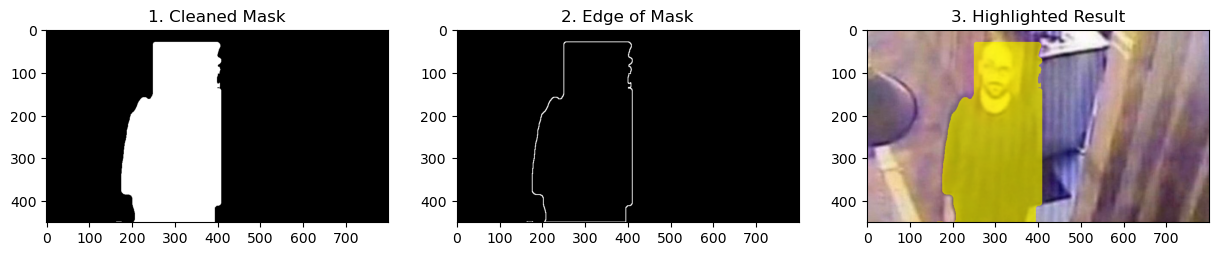

In [78]:
tinggi, lebar = cctv.shape[:2]

mask = np.zeros((tinggi, lebar), dtype=np.uint8)

mask[:, 160:410] = 255

rata_rgb = np.sum(cctv, axis=2, dtype=np.uint16) // 3

area_1 = rata_rgb[0:250, 160:210]
mask[0:250, 160:210][area_1 < 70] = 0

area_2 = rata_rgb[:, 350:410]
mask[:, 350:410][area_2 > 130] = 0

mask[10:180, 230:390] = 255

area_3 = img_smoothed[180:tinggi, 185:395]
mask[180:tinggi, 185:395][area_3 < 180] = 255

area_4 = img_smoothed[:, 160:250]
mask[:, 160:250][area_4 > 104] = 0

mask[0:30, :] = 0

mask = filter(mask, 9, 'median')
mask = np.where(mask > 127, 255, 0).astype(np.uint8)

edge_line = hitung_tepi(mask, sobelx, sobely)
edge_line = np.where(edge_line > 30, 255, 0).astype(np.uint8)

highlight = cctv.copy().astype(np.float32)

body_mask = (mask == 255)

r = highlight[:, :, 0]
g = highlight[:, :, 1]
b = highlight[:, :, 2]

r[body_mask] = r[body_mask] * 0.4 + 255 * 0.6
g[body_mask] = g[body_mask] * 0.4 + 255 * 0.6
b[body_mask] = b[body_mask] * 0.15

highlight = np.clip(highlight, 0, 255).astype(np.uint8)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(mask, cmap='gray')
plt.title('1. Cleaned Mask')


plt.subplot(1, 3, 2)
plt.imshow(edge_line, cmap='gray')
plt.title('2. Edge of Mask')

plt.subplot(1, 3, 3)
plt.imshow(highlight)
plt.title('3. Highlighted Result')

plt.show()

### Analisis Masking dan Highlight Objek Manusia

Tahapan ini bertujuan untuk memisahkan dan menonjolkan (*highlight*) objek manusia dari latar belakang citra CCTV agar keberadaan subjek lebih mudah diidentifikasi.

**Langkah-Langkah Pemrosesan:**
1. **Pembuatan Masking:** Menggunakan kombinasi pemotongan area (*slicing* koordinat) dan penyeleksian nilai intensitas piksel (*thresholding*) pada area tubuh untuk menandai subjek. Area subjek diisi nilai putih (255), sedangkan latar belakang diisi hitam (0).
2. **Pembersihan Mask:** Menggunakan filter **Median** (ukuran kernel 9) untuk membersihkan sisa-sisa *noise* (titik-titik putih di luar objek) dan merapatkan area *mask* agar bentuk siluet menjadi solid.
3. **Ekstraksi Garis Tepi:** *Mask* yang sudah bersih dilewatkan pada fungsi `hitung_tepi` (operator Sobel) untuk mendapatkan garis batas (*outline*) yang tegas di sekeliling tubuh subjek.
4. **Penerapan Highlight:** Area yang ditandai oleh *mask* pada citra asli dimodifikasi nilai saluran warna RGB-nya. Saluran Merah (R) dan Hijau (G) ditingkatkan intensitasnya, sementara saluran Biru (B) diturunkan untuk menghasilkan **efek *overlay* berwarna kuning semi-transparan** yang membuat subjek terlihat sangat menonjol tanpa menutupi tekstur aslinya.

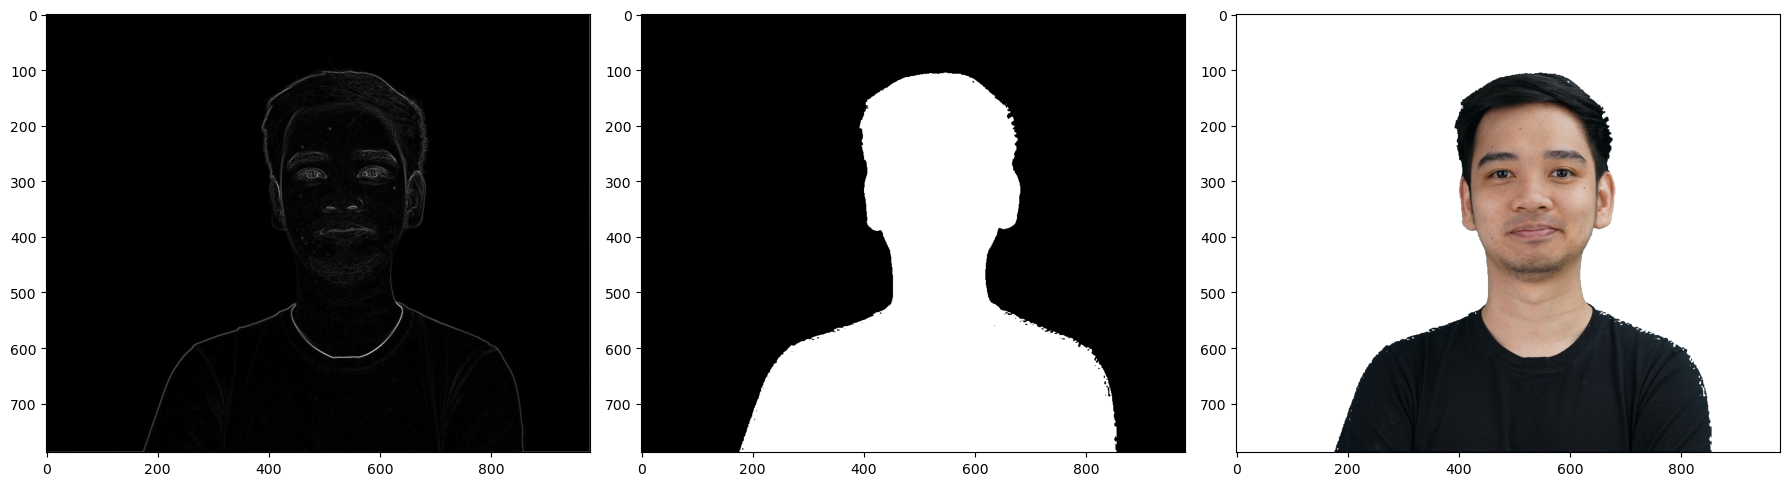

In [80]:
david = cv.imread("david.jpg")
david_rgb = cv.cvtColor(david, cv.COLOR_BGR2RGB)

david_gray = cv.cvtColor(david_rgb, cv.COLOR_RGB2GRAY)
tepi_david = edge(david_gray, sobelx, sobely)

height, width, _ = david_rgb.shape

david_no_bg = np.zeros_like(david_rgb)
david_putih = np.zeros_like(david_rgb) 

for i in range(height):
    for j in range(width):
        r = int(david_rgb[i, j, 0])
        g = int(david_rgb[i, j, 1])
        b = int(david_rgb[i, j, 2])
        
        if g > (r + 15) and b > (r + 15): 
            david_no_bg[i, j] = [255, 255, 255]
        else:
            david_no_bg[i, j] = [r, g, b]

        if (g > (r + 15) and b > (r + 15)): 
            david_putih[i, j] = [0, 0, 0] 
        else:
            david_putih[i, j] = [255, 255, 255] 

plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.imshow(tepi_david, cmap='gray')

plt.subplot(1, 3, 2)
plt.imshow(david_putih)

plt.subplot(1, 3, 3)
plt.imshow(david_no_bg)


plt.tight_layout()
plt.show()

### Analisis Proses Deteksi Tepi dan Background Removal

**1. Proses Deteksi Tepi (Edge Detection)**
Citra awal (berwarna) dikonversi terlebih dahulu menjadi *grayscale* (derajat keabuan). Setelah itu, citra tersebut diproses menggunakan fungsi konvolusi dengan operator tepi (seperti matriks Sobel). Hasilnya adalah peta kontur yang menonjolkan garis batas perubahan kontras yang tajam, seperti lekuk wajah, batas rambut, dan garis pakaian subjek.

**2. Pembuatan Mask Background (Pemisahan Kanal RGB)**
Berbeda dengan citra CCTV sebelumnya yang menggunakan *thresholding* intensitas gelap-terang, di sini kita memanfaatkan pemisahan kanal warna RGB. Karena latar belakang pas foto berwarna toska (campuran dominan hijau dan biru), setiap piksel dievaluasi menggunakan logika perbandingan matriks: **jika nilai Green dan Blue pada piksel tersebut jauh lebih tinggi daripada nilai Red**, maka area tersebut ditandai sebagai latar belakang (*background*). Sebaliknya, area wajah dan pakaian ditandai sebagai *foreground*. Pemisahan ini menghasilkan siluet hitam-putih (*masking*).

**3. Penghilangan Background (Background Removal)**
Tahap terakhir adalah menerapkan *masking* yang sudah dibuat ke citra RGB asli. Berdasarkan kondisi pelolosan piksel sebelumnya, program akan menulis ulang warna kanvas. Area yang terdeteksi sebagai subjek (*foreground*) akan mempertahankan nilai piksel aslinya, sedangkan area yang terdeteksi sebagai latar belakang (*background* toska) nilainya akan ditimpa menjadi warna putih murni secara keseluruhan (RGB: 255, 255, 255).

### KESIMPULAN

Berdasarkan seluruh percobaan, dapat disimpulkan bahwa perbaikan kualitas citra dan deteksi tepi merupakan dua proses yang saling berkaitan. Tahap perbaikan citra, seperti smoothing dan pengurangan noise menggunakan filter spasial, berfungsi untuk membersihkan gambar tanpa menghilangkan detail penting. Hasil citra yang lebih bersih membuat proses deteksi tepi menggunakan metode seperti Sobel, Prewitt, dan Roberts menjadi lebih akurat dalam mengenali batas objek. Oleh karena itu, kualitas deteksi tepi sangat dipengaruhi oleh kualitas citra awal. Kombinasi kedua proses ini juga memungkinkan penerapan teknik pengolahan citra yang lebih kompleks, seperti isolasi siluet manusia pada CCTV dan penghapusan latar belakang pada pas foto.